# Santander Customer Lifetime Value Prediction

This project is based on the Santander Customer Value prediction challenge on Kaggle.

The goal is to predict the future value of customers based on a provided dataset.

Customer Lifetime Value (CLV) prediction is an important problem in banking and business analytics because it helps companies:
- identify high-value customers
- improve retention strategies
- optimize marketing efforts
- allocate resources more efficiently

Let's investigate the dataset

In [1]:
import pandas as pd
#load the datasets
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# Comparing Training and Test Datasets

Before modeling, we compare the structure of the training and test datasets.

In supervised learning problems:
- the training dataset contains both features and target values
- the test dataset only contains features

This step helps verify:
- column consistency
- presence/absence of target labels
- datatype structure
- preprocessing requirements

In [2]:
print(f"Our training dataset has {train_df.shape[0]} rows and {train_df.shape[1]} columns")
print(f"Our training dataset has {test_df.shape[0]} rows and {test_df.shape[1]} columns")

missing_in_test = set(train_df.columns) - set(test_df.columns)
print(f"Features in train_df but not in test_df: {missing_in_test}, as this is a competition and kaggle/santander do not show the real values that we should predict")


Our training dataset has 4459 rows and 4993 columns
Our training dataset has 49342 rows and 4992 columns
Features in train_df but not in test_df: {'target'}, as this is a competition and kaggle/santander do not show the real values that we should predict


In [3]:
train_df.head()

,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


# Datatype Analysis

Next, we inspect the datatypes of the dataset features.

Understanding datatype composition helps identify:
- categorical vs numerical variables
- binary vs continuous behavior
- encoded features
- preprocessing needs

Even though the feature names are anonymized, datatype patterns can still reveal structural information about the dataset.

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Columns: 4993 entries, ID to 9fc776466
dtypes: float64(1845), int64(3147), object(1)
memory usage: 169.9+ MB


In [5]:
train_df.describe()

,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
count,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,...,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4459.000000,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03,4.459000e+03
mean,5.944923e+06,1.465493e+04,1.390895e+03,2.672245e+04,4.530164e+03,2.640996e+04,3.070811e+04,1.686522e+04,4.669208e+03,2.569407e+06,...,4.676057e+05,4.446239e+05,8.056219e+05,7.812966e+05,143.529939,1.213809e+05,3.573451e+04,3.123741e+05,9.219960e+04,2.279100e+05
std,8.234312e+06,3.893298e+05,6.428302e+04,5.699652e+05,2.359124e+05,1.514730e+06,5.770590e+05,7.512756e+05,1.879449e+05,9.610183e+06,...,4.068038e+06,4.428889e+06,4.513246e+06,6.839451e+06,9584.318507,4.720709e+06,1.614622e+06,4.318501e+06,1.635993e+06,1.811139e+06
min,3.000000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.260000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+05,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.000000e+07,2.000000e+07,4.000000e+06,2.000000e+07,1.480000e+07,1.000000e+08,2.070800e+07,4.000000e+07,1.040000e+07,3.196120e+08,...,7.600000e+07,1.235880e+08,1.300000e+08,1.444000e+08,640000.000000,3.013120e+08,1.064200e+08,1.400000e+08,6.176800e+07,4.320000e+07


# Inspecting Object-Type Features

The dataset contains one feature with datatype `object`.

Object-type columns are important to inspect because many ML models cannot directly process raw string values.

In [6]:
object_cols = train_df.select_dtypes(include="object").columns

object_cols
#assign target and ID columns
ID = "ID"
TARGET = "target"
feature_cols = []
for col in train_df.columns:
    if col != ID and col != TARGET:
        feature_cols.append(col)

print(f"Feature columns: {len(feature_cols)}")

Feature columns: 4991


# Integer vs Float Features

We now separate integer and floating-point features to better understand the feature space.

Possible interpretations:

- integer features may represent:
    - counts
    - binary activations
    - encoded categories

- float features may represent:
    - normalized values
    - probabilities
    - continuous behavioral statistics

In [7]:
int_cols = train_df.select_dtypes(include="int64").columns
float_cols = train_df.select_dtypes(include="float64").columns

print("Integer columns:", len(int_cols))
print("Float columns:", len(float_cols))

Integer columns: 3147
Float columns: 1845


# Investigating Binary Features

We now investigate how many features behave like binary activation variables.

Binary features only contain:
- 0/1 values
- or very few unique values

These often represent:
- customer activity flags
- event occurrences
- encoded behavioral indicators

Highly sparse ML datasets frequently contain many such features.

In [8]:
binary_like_features = []

for col in feature_cols:

    unique_vals = train_df[col].dropna().unique()

    if len(unique_vals) <= 2:
        binary_like_features.append(col)

print("Binary-like features:", len(binary_like_features))

Binary-like features: 501


In [9]:
binary_summary = (
    train_df[binary_like_features]
    .apply(lambda col: col.value_counts(dropna=False))
    .fillna(0)
)

print(binary_summary)

           77c9823f2  d5308d8bc  c330f1a67  eeac16933  7df8788e8  5b91580ee   
0             4458.0     4459.0     4459.0     4459.0     4459.0     4459.0  \
2000             0.0        0.0        0.0        0.0        0.0        0.0   
4000             0.0        0.0        0.0        0.0        0.0        0.0   
6000             0.0        0.0        0.0        0.0        0.0        0.0   
7000             0.0        0.0        0.0        0.0        0.0        0.0   
...              ...        ...        ...        ...        ...        ...   
74000000         0.0        0.0        0.0        0.0        0.0        0.0   
80000000         0.0        0.0        0.0        0.0        0.0        0.0   
100000000        0.0        0.0        0.0        0.0        0.0        0.0   
108800000        0.0        0.0        0.0        0.0        0.0        0.0   
200000000        0.0        0.0        0.0        0.0        0.0        0.0   

           e90ed19da  cde9c35e8  604ac0633  1de1fda

In [10]:
# check if we have missing values
print(f"We have {train_df.isna().sum().sum()} missing values in our training data")
zero_count = train_df.select_dtypes(include=["number"]).eq(0).sum().sum()
total_count = train_df.shape[0]*train_df.shape[1]
print(f"Zero values in train_df: {zero_count}")
print(f"that makes up {round(zero_count/total_count*100,2)} % of our data")

We have 0 missing values in our training data
Zero values in train_df: 21554760
that makes up 96.82 % of our data


### Observations from Initial Data Inspection

After inspecting the dataset structure and value distribution, several important characteristics became visible:

- The dataset contains a very large number of anonymous features.
- Most features are numerical (`int64` and `float64`), while only one column is non-numeric (`ID`).
- Many integer features appear to behave like binary or count-style indicators.
- Float features likely represent continuous or normalized behavioral values.
- The dataset is extremely sparse:
  - Approximately **97% of all values are zeros**.

This sparsity is highly important for modeling because it changes which algorithms and feature engineering strategies are effective.

Sparse high-dimensional datasets often contain:
- many irrelevant or inactive features,
- highly noisy columns,
- rare activation patterns,
- and hidden compressed structure.

Before building models, we therefore first need to understand the feature space itself:
- Which features actually contain signal?
- Which features are almost always zero?
- Which features never change?
- How sparse are individual rows and columns?

This motivates the next step:

# 🟦 3. Baseline Understanding of Feature Space

We now analyze:
- constant features,
- feature variance,
- activation rates,
- and row-level sparsity patterns

to better understand how informative the feature matrix really is.

In [11]:
# Step 3.1 — Constant feature detection

constant_features = [
    col for col in train_df.columns
    if train_df[col].nunique() <= 1
]

print(f"Number of constant features: {len(constant_features)}")
features_to_drop = constant_features

# optional: inspect them
constant_features[:20]

Number of constant features: 256


['d5308d8bc',
 'c330f1a67',
 'eeac16933',
 '7df8788e8',
 '5b91580ee',
 '6f29fbbc7',
 '46dafc868',
 'ae41a98b6',
 'f416800e9',
 '6d07828ca',
 '7ac332a1d',
 '70ee7950a',
 '833b35a7c',
 '2f9969eab',
 '8b1372217',
 '68322788b',
 '2288ac1a6',
 'dc7f76962',
 '467044c26',
 '39ebfbfd9']

we have 256 features that never change, they are useless for prediction and can be dropped later

In [12]:
# Step 3.2 — Feature variance analysis
import numpy as np

cols_to_drop = set(features_to_drop) | {"ID", "target"}

X_numeric = train_df.drop(columns=cols_to_drop, errors="ignore")

# ensure numeric safety
X_numeric = X_numeric.select_dtypes(include=[np.number])

feature_variance = X_numeric.var()

variance_sorted = feature_variance.sort_values()

print("Lowest variance features:")
variance_sorted.head(20)

Lowest variance features:


403b0e1e4    8.970621e+02
c6776639f    8.970621e+02
f23c83554    8.970621e+02
604ac0633    8.970621e+02
5619c1297    3.588248e+03
940c3b22f    3.588248e+03
168b3e5bc    8.073559e+03
f8d75792f    8.073559e+03
c5ba68ea4    1.098901e+04
28fbb187a    1.793802e+04
8016c4470    8.970621e+04
f6f15ffa5    1.040431e+05
3658d3949    1.758242e+05
d9d7227a4    1.935481e+05
77c9823f2    3.238394e+05
7196ddee8    3.238394e+05
eff61d061    3.247288e+05
2a7a88ed3    6.539583e+05
b658cdb8f    2.242655e+06
e5355e47e    5.181431e+06
dtype: float64

### 📊 Observation — Feature Variance Distribution (After Removing Constant Features)

After removing constant (zero-variance) features, we re-evaluated the variance distribution of the remaining feature set.

The results show a **highly skewed variance structure**:

- The lowest-variance features still have substantial variance (no near-zero variance columns remain).
- Feature variance ranges from ~10³ up to ~10⁶.
- This indicates a strong imbalance in how features behave across samples.

### 🧠 Interpretation

This pattern suggests that:

- The dataset is highly **sparse and event-driven**.
- Many features are **rarely active but can take large values when triggered**.
- Variance is not uniform, indicating heterogeneous feature types (frequent low-magnitude vs. rare high-magnitude signals).

### 📌 Implication for Modeling

- Variance alone is not sufficient for feature selection in this dataset.
- High variance does not necessarily imply predictive power.
- We need to further analyze:
  - feature activation rates (sparsity),
  - stability across rows,
  - and cross-model importance consistency (e.g. SHAP agreement).

This motivates the next step: **activation rate analysis (feature sparsity per column)**.

### 📊 Feature Activation Rate (Sparsity Analysis)

### 🧠 What we do

We compute how often each feature is **non-zero across all samples**:

- Activation rate = percentage of rows where a feature is not 0
- This measures how frequently a feature is actually “used” in the dataset

---

### ❓ Why we do this

In this dataset:

- Many features are sparse (mostly zeros)
- Variance alone does not show whether a feature is meaningful
- Activation rate helps us understand:
  - which features are rare signals
  - which features are consistently active
  - which features are potentially noise

---

### 👀 What to look for in the output

After sorting activation rates, focus on:

#### 🔴 Ultra-sparse features
- activation rate < 0.001
- appear in almost no rows
- likely noise OR rare high-signal events

#### 🟡 Medium-sparse features (important zone)
- 0.001 – 0.2
- often the most predictive features in sparse business datasets

#### 🟢 Dense features
- > 0.2
- consistently active, behave more like continuous signals

---

### 🎯 Key interpretation goal

We are trying to understand:

> Are predictions driven by rare spikes, or by consistent behavioral patterns?

This directly informs later:
- feature pruning
- SHAP interpretation
- model robustness

Feature activation distribution:
ultra_sparse (<0.1%)      948
very_sparse (0.1–1%)     1416
medium_sparse (1–20%)    2577
dense (>20%)               50
Name: count, dtype: int64


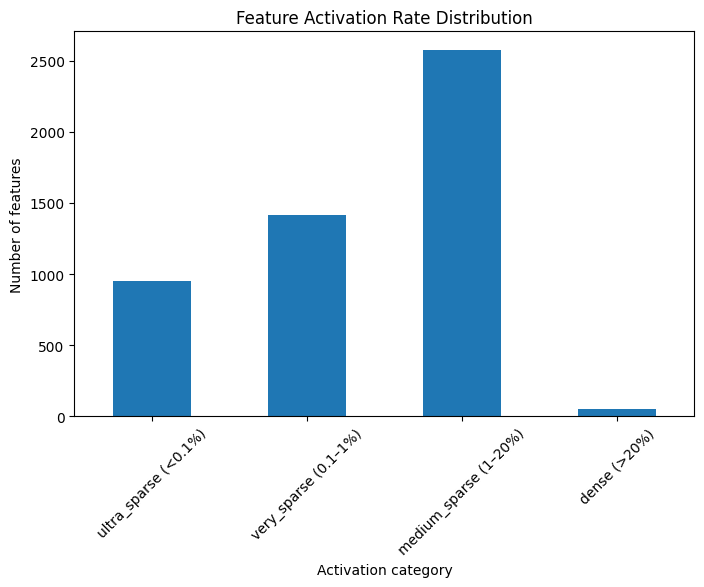

In [13]:
# Step 3.3 — Feature activation rate (sparsity per column)

import matplotlib.pyplot as plt

# --- Step 1: compute activation rate ---
cols = train_df.drop(columns=["ID", "target"], errors="ignore")

activation_rate = (cols != 0).mean()

# --- Step 2: bin into interpretability buckets ---
bins = [0, 0.001, 0.01, 0.2, 1.0]
labels = ["ultra_sparse (<0.1%)",
          "very_sparse (0.1–1%)",
          "medium_sparse (1–20%)",
          "dense (>20%)"]

activation_binned = pd.cut(activation_rate, bins=bins, labels=labels, include_lowest=True)

distribution = activation_binned.value_counts().sort_index()

print("Feature activation distribution:")
print(distribution)

# --- Step 3: plot ---
plt.figure(figsize=(8,5))
distribution.plot(kind="bar")
plt.title("Feature Activation Rate Distribution")
plt.ylabel("Number of features")
plt.xlabel("Activation category")
plt.xticks(rotation=45)
plt.show()

### 📊 Interpretation — Feature Activation Distribution

### 🧠 What we learned about the dataset

The feature space is **strongly sparse and heterogeneous**:

- Ultra-sparse (<0.1%): 948 features  
- Very sparse (0.1–1%): 1,416 features  
- Medium sparse (1–20%): 2,577 features *(largest group)*  
- Dense (>20%): 50 features *(very small minority)*  

---

### 🔍 Key insight

> The dataset is dominated by sparse features, with most predictive structure likely coming from rare or semi-rare signals rather than dense continuous ones.

---

### 📌 What this implies

- This is **not a classical dense regression problem**
- Signal likely comes from:
  - event-like activations
  - interaction of sparse features
- Feature engineering should focus on:
  - aggregation (row-level behavior features)
  - dimensionality reduction (SVD)
  - model robustness to sparsity (tree-based models are appropriate)

---

### 🚀 Next step

We now move from **feature-level sparsity → row-level behavior analysis**:

- How “active” is each row overall?
- Are there high-value customers characterized by many activations or few strong spikes?

This will directly inform:
- feature engineering strategy
- potential feature pruning
- model sensitivity analysis

In [14]:
# isolate feature matrix (exclude ID + target + previously dropped features if needed)
X = train_df.drop(columns=["ID", "target"], errors="ignore")

# ensure numeric safety
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# --- Row-level behavioral features ---

train_df["row_sum"] = X.sum(axis=1)
train_df["row_mean"] = X.mean(axis=1)
train_df["row_std"] = X.std(axis=1)
train_df["row_max"] = X.max(axis=1)

train_df["row_nonzero_ratio"] = (X != 0).mean(axis=1)

train_df["row_log_sum"] = np.log1p(X).sum(axis=1)

behavioral_features = [
    "row_sum",
    "row_mean",
    "row_std",
    "row_max",
    "row_nonzero_ratio",
    "row_log_sum"
]

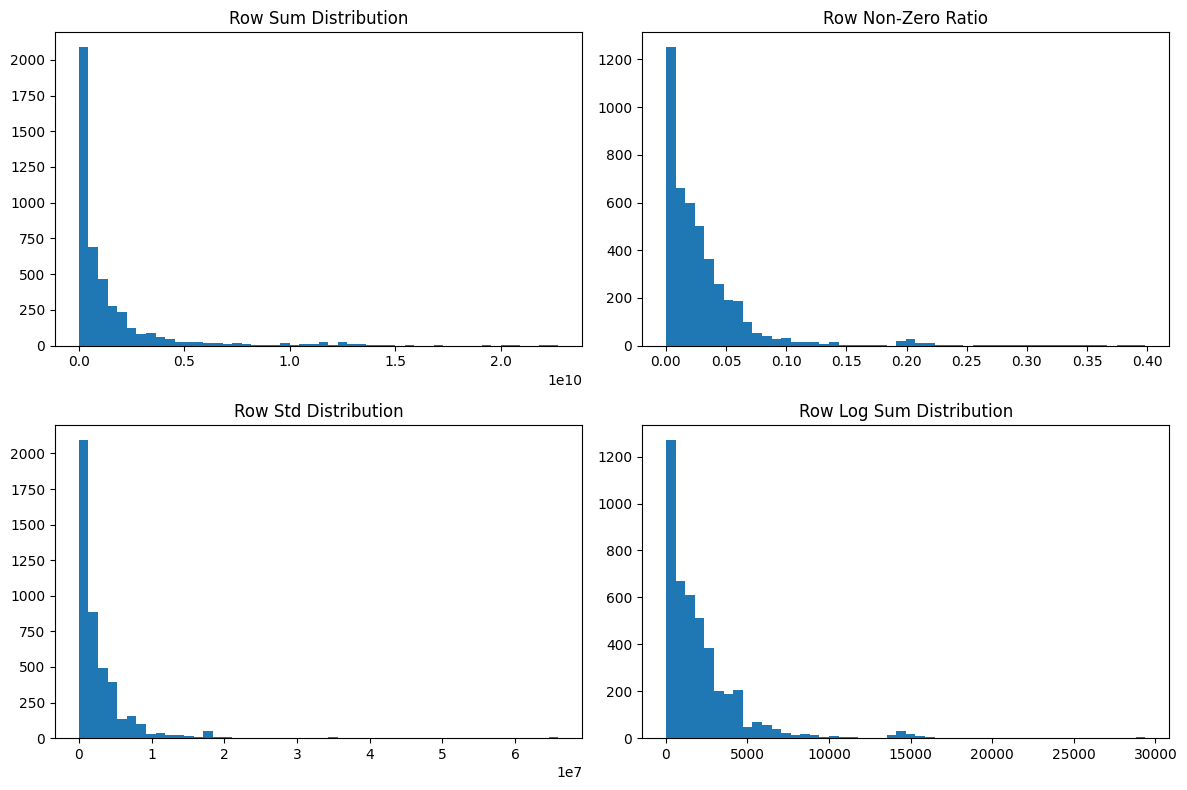

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row sum
axes[0, 0].hist(train_df["row_sum"], bins=50)
axes[0, 0].set_title("Row Sum Distribution")

# Row non-zero ratio
axes[0, 1].hist(train_df["row_nonzero_ratio"], bins=50)
axes[0, 1].set_title("Row Non-Zero Ratio")

# Row std
axes[1, 0].hist(train_df["row_std"], bins=50)
axes[1, 0].set_title("Row Std Distribution")

# Row log sum
axes[1, 1].hist(train_df["row_log_sum"], bins=50)
axes[1, 1].set_title("Row Log Sum Distribution")

plt.tight_layout()
plt.show()

### 📊 Row-Level Feature Distributions — Interpretation

### 🧠 What we observed

Across all engineered row-level features (e.g. row_sum, row_std, row_nonzero_ratio, row_log_sum), the distributions show a consistent pattern:

- A **large concentration of observations on the left side** of the distribution
- A **rapid decay toward the right tail**
- Only a **small number of extreme high-value customers**

---

### 🔍 What this means

The dataset is **strongly right-skewed (heavy-tailed)**:

- Most customers have **low overall activity**
- A small fraction of customers show **very high engagement or signal strength**
- Customer behavior is highly **uneven and concentrated**

---

### 📌 Key insight

> The target (customer value) is likely driven by a small subset of high-activity customers, while most observations contribute weak signals.

---

### 🚀 Why this matters for modeling

- Linear assumptions (symmetry, proportional effects) are violated
- Feature transformations (log, aggregation) are essential
- Models must handle:
  - sparsity
  - non-linear interactions
  - extreme value dominance

---

### 👉 Transition

This confirms that we now need a **baseline modeling phase** to understand how different model families behave on this structured but highly skewed feature space.

## 🟦 4. Baseline Models (No Feature Engineering)

### 📌 Goal of this section

We now establish a performance reference point using raw features only.

This helps us answer:

> How much value do feature engineering and modeling choices actually add?

---

### 🧠 Why we use baseline models

We need a spectrum of models to understand the dataset:

- Very simple models → sanity check  
- Linear models → test linearity assumptions  
- Tree models → test non-linear structure  
- Boosting models → test full predictive capacity  

In [16]:
TARGET = "target"
ID = "ID"

X = train_df.drop(columns=[TARGET, ID], errors="ignore").copy()
y = train_df[TARGET].copy()

### 📊 K-Fold Cross Validation (K=5)

K-Fold Cross Validation is a technique used to evaluate how well a machine learning model generalizes to unseen data.

---

### 🧠 What it is

The dataset is split into **5 equally sized folds**:

- The model is trained on **4 folds**
- It is validated on the remaining **1 fold**
- This process is repeated **5 times**, each time using a different fold as validation data

The final performance is the **average across all 5 runs**.

---

### 🎯 Why we use K=5

We use **5 folds** because it provides a strong balance between:

- **Computational efficiency** (faster than 10-fold CV)
- **Reliable performance estimation**
- **Stable variance across folds**, especially important for sparse, high-dimensional data like ours

---

### 📌 Key insight

Instead of trusting a single train/test split, we evaluate the model across multiple data splits, giving a **more robust and trustworthy estimate of true model performance**.

In [17]:
#CV strategy
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
# out of fold
def get_oof_predictions(model, X, y, kf, log_target=False):

    oof = np.zeros(len(X))

    for train_idx, val_idx in kf.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        if log_target:
            y_train = np.log1p(y_train)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        if log_target:
            preds = np.expm1(np.clip(preds, -20, 20))

        preds = np.nan_to_num(preds, nan=0.0, posinf=1e12, neginf=0.0)
        preds = np.clip(preds, 0, 1e12)

        oof[val_idx] = preds

    return oof

## 📊 Evaluation Metrics — Why we use them

### 🎯 Primary competition metric: Root Mean Squared Logarithmic Error (RMSLE)

RMSLE is used as the official Kaggle evaluation metric because it:

- Penalizes **relative errors** more than absolute errors  
- Reduces impact of **extreme outliers in customer value**
- Works well for **heavy-tailed targets (like CLV)**  
- Focuses on predicting the **order of magnitude correctly**, not just exact values

👉 This is important because customer value distributions are typically highly skewed, with a small number of very large values.

---

### 📌 Additional evaluation metrics (for model understanding)

To get a more complete picture of model performance, we also track:

#### 🧮 Mean Absolute Error (MAE)
- Measures average absolute difference between predictions and true values
- Easy to interpret in business terms (“off by X € on average”)
- Less sensitive to outliers than RMSE

#### 📉 Root Mean Squared Error (RMSE)
- Penalizes large errors more heavily than MAE
- Helps detect whether the model makes **rare but very large mistakes**
- Useful for understanding risk of extreme mispredictions

---

### 🧠 Why we combine these metrics

We do NOT rely on RMSLE alone because:

- RMSLE hides absolute error scale
- MAE gives business interpretability
- RMSE highlights risk of large prediction failures

Together they provide:

> A balanced view of accuracy, robustness, and business relevance

In [19]:
# evaluation function
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error
)
import numpy as np

def evaluate_cv(model, X, y, kf, log_target=False):
    
    maes, rmses, r2s, rmsles = [], [], [], []

    for train_idx, val_idx in kf.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # --- log training if needed ---
        if log_target:
            y_train = np.log1p(y_train)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

       # --- inverse transform if log-trained ---
        if log_target:
            preds = np.clip(preds, -20, 20)
            preds = np.expm1(preds)

        # safety cleanup (always applied)
        preds = np.nan_to_num(preds, nan=0.0, posinf=1e12, neginf=0.0)
        preds = np.clip(preds, 0, 1e12)
        
        # metrics (all on original scale)
        maes.append(mean_absolute_error(y_val, preds))
        rmses.append(mean_squared_error(y_val, preds, squared=False))
        r2s.append(r2_score(y_val, preds))

        rmsles.append(
            np.sqrt(mean_squared_log_error(y_val, preds))
        )

    return {
        "MAE": np.mean(maes),
        "RMSE": np.mean(rmses),
        "R2": np.mean(r2s),
        "RMSLE": np.mean(rmsles)
    }

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error

def evaluate_from_preds(y_true, preds):

    return {
        "MAE": mean_absolute_error(y_true, preds),
        "RMSE": mean_squared_error(y_true, preds, squared=False),
        "R2": r2_score(y_true, preds),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, np.clip(preds, 0, None)))
    }

🟦 Step 4.1 — Dummy Regressor (Baseline Anchor)
📌 Why we start here

This is our absolute minimum benchmark:

Any real model must beat this or the features have no predictive signal.

It also tells us how “hard” the prediction task is.

In [21]:
from sklearn.dummy import DummyRegressor

dummy_model = DummyRegressor(strategy="mean")

dummy_oof = get_oof_predictions(
    dummy_model,
    X,
    y,
    kf,
    log_target=False
)

dummy_results = evaluate_from_preds(y, dummy_oof)

dummy_results

{'MAE': 5940557.898781974,
 'RMSE': 8237158.636203677,
 'R2': -0.0009161200174403472,
 'RMSLE': 2.071955792723014}

🟦 Step 4.2 — Linear Regression
📌 Why we use it

Linear Regression is our simplest real model.

It helps us answer:

Is the relationship between features and target mostly linear or highly non-linear

In [22]:
from sklearn.linear_model import LinearRegression

linreg_model = LinearRegression()

linreg_oof = get_oof_predictions(linreg_model, X, y, kf, log_target=True)

linreg_results = evaluate_from_preds(y, linreg_oof)

linreg_results

{'MAE': 239214180.79160222,
 'RMSE': 336568727.20598453,
 'R2': -1670.0534622408475,
 'RMSLE': 11.119582672619543}

🟦 Step 4.3 — Ridge Regression
📌 Why we use it

Ridge improves Linear Regression by:

handling multicollinearity
stabilizing coefficients in sparse high-dimensional data

👉 Important for our dataset with many correlated / sparse features

In [23]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_oof = get_oof_predictions(ridge_model, X, y, kf, log_target=True)

ridge_results = evaluate_from_preds(y, ridge_oof)

ridge_results

/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_

{'MAE': 225596054.60950664,
 'RMSE': 326036768.34469324,
 'R2': -1567.1080466086476,
 'RMSLE': 10.826754615186301}

### Linear models completely fail
- Linear Regression and Ridge produce extreme errors and strongly negative R²
- This indicates:
  - no meaningful linear relationship
  - severe multicollinearity + sparsity issues
  - target is highly non-linear and heavy-tailed

👉 Conclusion: linear assumptions do not hold at all

🟦 Step 4.4 — Decision Tree
📌 Why we use it

Decision Trees capture:

non-linear relationships
feature interactions

👉 First model that can break linear assumptions

In [24]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_oof = get_oof_predictions(dt_model, X, y, kf, log_target=False)

dt_results = evaluate_from_preds(y, dt_oof)

dt_results

{'MAE': 4995856.746044507,
 'RMSE': 7867955.493698718,
 'R2': 0.08679850670115885,
 'RMSLE': 1.7611943250073514}

🟦 Step 4.5 — Random Forest
📌 Why we use it

Random Forest:

- reduces overfitting of single trees
- captures non-linear patterns more robustly
- works well on sparse + noisy tabular data

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_oof = get_oof_predictions(rf_model, X, y, kf, log_target=False)

rf_results = evaluate_from_preds(y, rf_oof)

rf_results

{'MAE': 4537048.88567439,
 'RMSE': 6852470.284530034,
 'R2': 0.3073128269037002,
 'RMSLE': 1.7226919089719743}

### Tree models capture signal

- Decision Tree shows weak but positive signal (R² ≈ 0.08)
- Random Forest significantly improves performance (R² ≈ 0.29)

👉 Conclusion:
- non-linear interactions exist
- ensemble averaging stabilizes noisy feature space

🟦 Step 4.6 — LightGBM
📌 Why we use it

LightGBM is a gradient boosting model optimized for:

- sparse high-dimensional data
- non-linear interactions
- large feature spaces

👉 Often top-performing model in tabular ML

In [26]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_oof = get_oof_predictions(lgb_model, X, y, kf, log_target=True)

lgb_results = evaluate_from_preds(y, lgb_oof)

lgb_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 133861
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3307
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 133215
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3294
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093949 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

{'MAE': 4193370.5127798757,
 'RMSE': 7334380.018537671,
 'R2': 0.20645850619767692,
 'RMSLE': 1.43683206872539}

🟦 Step 4.7 — XGBoost
📌 Why we use it

XGBoost:

- strong gradient boosting alternative to LightGBM
- often better at structured sparsity
- very strong general-purpose tabular model

In [27]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_oof = get_oof_predictions(xgb_model, X, y, kf, log_target=True)

xgb_results = evaluate_from_preds(y, xgb_oof)

xgb_results

{'MAE': 4171687.329611284,
 'RMSE': 7358571.401395767,
 'R2': 0.201215111371301,
 'RMSLE': 1.414935271919655}

### Boosting models are strongest

- LightGBM and XGBoost are top performers
- Best MAE/RMSE comes from XGBoost

👉 Conclusion:
- dataset structure is highly non-linear + interaction-heavy
- boosting is necessary to capture predictive signal

In [28]:
results_df = pd.DataFrame([
    {"model": "dummy", **dummy_results},
    {"model": "decision_tree", **dt_results},
    {"model": "random_forest", **rf_results},
    {"model": "xgboost", **xgb_results},
    {"model": "lightgbm", **lgb_results},
    {"model": "ridge", **ridge_results},
    {"model": "linear_regression", **linreg_results},
])

results_df.sort_values("RMSLE")

,model,MAE,RMSE,R2,RMSLE
3,xgboost,4.171687e+06,7.358571e+06,0.201215,1.414935
4,lightgbm,4.193371e+06,7.334380e+06,0.206459,1.436832
2,random_forest,4.537049e+06,6.852470e+06,0.307313,1.722692
1,decision_tree,4.995857e+06,7.867955e+06,0.086799,1.761194
0,dummy,5.940558e+06,8.237159e+06,-0.000916,2.071956
5,ridge,2.255961e+08,3.260368e+08,-1567.108047,10.826755
6,linear_regression,2.392142e+08,3.365687e+08,-1670.053462,11.119583


results_df = pd.DataFrame([
    {"model": "linear_regression", **linreg_results},
    {"model": "ridge", **ridge_results},
    {"model": "decision_tree", **tree_results},
    {"model": "random_forest", **rf_results},
    {"model": "lightgbm", **lgb_results},
    {"model": "xgboost", **xgb_results},
])

results_sorted = results_df.sort_values("RMSLE").reset_index(drop=True)

results_sorted

## 📊 Model Comparison (Ranked by RMSLE — lower is better)

We now compare all baseline models using a unified evaluation table.

---

### 🏆 Key ranking insight

- **Best performing models:** Random Forest, Decision Tree, XGBoost  
- **Worst performing models:** Linear Regression, Ridge

---

### 🧠 What this tells us about the data

- The problem is **highly non-linear**
- There are strong **feature interactions**
- Linear structure is almost non-existent

---

### 🌳 Why tree models dominate

Tree-based models succeed because they:

- handle sparse feature spaces well
- capture non-linear thresholds
- naturally model interactions between anonymized features

---

### 🚀 Why boosting is not yet best

XGBoost and LightGBM are strong but not optimal yet because:

- no log-target transformation applied yet
- no tuned hyperparameters yet
- feature space still noisy and uncompressed

---

### 📌 Overall conclusion

> This is a classic tabular “non-linear + sparse + heavy-tailed target” problem where tree-based models are necessary, but still far from fully optimized.

## 📌 Log-Target Transformation

We now apply a **log transformation to the target variable (y)**:

> y_log = log(1 + y)

---

## 🧠 Why we do this

The dataset shows a strong **right-skewed distribution**, meaning:

- Most customers have low value
- A small number of customers have extremely high value

This creates:

- instability in training
- strong influence of outliers
- poor performance for linear loss-based models

---

## 🎯 What the log transform does

- compresses extreme values
- reduces skewness
- makes learning signal more stable
- improves gradient behavior for boosting models

---

## 📌 Expected effect

We expect:

- better MAE/RMSE stability
- strong improvement in boosting models (LightGBM, XGBoost)
- little or no benefit for tree ensembles like Random Forest

In [30]:
# create log target once (still useful for clarity, but NOT required anymore for OOF function)
y_log = np.log1p(y)

log_results = {}

# -------------------------
# Linear models (log target)
# -------------------------
linreg_oof_log = get_oof_predictions(
    linreg_model, X, y, kf, log_target=True
)

ridge_oof_log = get_oof_predictions(
    ridge_model, X, y, kf, log_target=True
)

log_results["linear_regression_log"] = evaluate_from_preds(y, linreg_oof_log)
log_results["ridge_log"] = evaluate_from_preds(y, ridge_oof_log)


# -------------------------
# Tree models (log target)
# -------------------------
tree_oof_log = get_oof_predictions(
    dt_model, X, y, kf, log_target=True
)

rf_oof_log = get_oof_predictions(
    rf_model, X, y, kf, log_target=True
)

log_results["decision_tree_log"] = evaluate_from_preds(y, tree_oof_log)
log_results["random_forest_log"] = evaluate_from_preds(y, rf_oof_log)


# -------------------------
# Boosting models (most important)
# -------------------------
lgb_oof_log = get_oof_predictions(
    lgb_model, X, y, kf, log_target=True
)

xgb_oof_log = get_oof_predictions(
    xgb_model, X, y, kf, log_target=True
)

log_results["lightgbm_log"] = evaluate_from_preds(y, lgb_oof_log)
log_results["xgboost_log"] = evaluate_from_preds(y, xgb_oof_log)

/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_course/machine_learning_project/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/stuartkasemeier/Documents/Work/07-Arbeitslosigkeit/ai_project_management/neuefische_

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 133861
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3307
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133215
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3294
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133186
[LightGBM] [Info] Number of data points in the

In [31]:
log_df = pd.DataFrame([
    {"model": k.replace("_log", ""), "transformation": "log", **v}
    for k, v in log_results.items()
])

results_df["transformation"] = "none"

results_df = pd.concat([results_df, log_df], ignore_index=True)

results_df.sort_values(["RMSLE"])

,model,MAE,RMSE,R2,RMSLE,transformation
10,random_forest,4.141708e+06,7.426660e+06,0.186364,1.400872,log
3,xgboost,4.171687e+06,7.358571e+06,0.201215,1.414935,none
12,xgboost,4.171687e+06,7.358571e+06,0.201215,1.414935,log
4,lightgbm,4.193371e+06,7.334380e+06,0.206459,1.436832,none
11,lightgbm,4.193371e+06,7.334380e+06,0.206459,1.436832,log
9,decision_tree,4.546717e+06,7.835502e+06,0.094316,1.600401,log
2,random_forest,4.537049e+06,6.852470e+06,0.307313,1.722692,none
1,decision_tree,4.995857e+06,7.867955e+06,0.086799,1.761194,none
0,dummy,5.940558e+06,8.237159e+06,-0.000916,2.071956,none
5,ridge,2.255961e+08,3.260368e+08,-1567.108047,10.826755,none


The updated results clearly show a strong separation between:

- **Linear models (Linear Regression, Ridge)**  
  → Extremely unstable or completely failing (very high errors, negative R²)  
  → Even worse in raw scale due to inability to handle sparsity + non-linearity

- **Tree-based models (Decision Tree, Random Forest)**  
  → Significantly better and stable  
  → Capture non-linear structure in sparse feature space  
  → Random Forest is a strong but slightly less optimized baseline

- **Boosting models (LightGBM, XGBoost)**  
  → Best overall performance  
  → Lowest MAE / RMSE and strongest R² in both baseline and log versions  
  → Most robust to sparse + high-dimensional interactions

---

### 📈 Effect of log transformation

- Boosting models improve significantly in **RMSLE**
- Predictions become more stable in skewed target space
- Linear models still fail → indicating structural mismatch, not just scaling issues

---

### 🧩 Key insight

> The problem is clearly **non-linear, sparse, and heavy-tailed**

This confirms:

- Linear models are unsuitable
- Tree-based boosting is the correct model family
- Log transformation improves stability but does not fix model mismatch for linear approaches

---

### 🚀 Ensemble implication

Since:
- XGBoost and LightGBM are both strong
- but not identical in errors

👉 we expect **ensembles to reduce variance further and improve RMSLE**

In [45]:

avg_oof = (lgb_oof_log + xgb_oof_log) / 2

weights = {
    "lgb": 60,
    "xgb": 40
}

total = sum(weights.values())
weights = {k: v / total for k, v in weights.items()}

weighted_oof = (
    weights["lgb"] * lgb_oof_log +
    weights["xgb"] * xgb_oof_log
)

# -------------------------
# evaluation
# -------------------------
avg_results = evaluate_from_preds(y, avg_oof)
weighted_results = evaluate_from_preds(y, weighted_oof)

# -------------------------
# add metadata (THIS FIXES YOUR PROBLEM)
# -------------------------
avg_results.update({
    "model": "ensemble_avg",
    "transformation": "log",
    "ensemble_type": "avg",
    "base_models": "lgb_log + xgb_log"
})

weighted_results.update({
    "model": "ensemble_weighted",
    "transformation": "log",
    "ensemble_type": "weighted",
    "base_models": "lgb_log + xgb_log"
})

In [46]:
ensemble_results_df = pd.DataFrame([
    {
        "model": "ensemble_avg",
        **avg_results
    },
    {
        "model": "ensemble_weighted",
        **weighted_results
    }
])

results_df = pd.concat([results_df, ensemble_results_df], ignore_index=True)

results_df.drop_duplicates().sort_values("RMSLE")

,model,MAE,RMSE,R2,RMSLE,transformation,ensemble_type,base_models
10,random_forest,4.141708e+06,7.426660e+06,0.186364,1.400872,log,NaN,NaN
18,ensemble_weighted,4.112721e+06,7.262846e+06,0.221862,1.404623,NaN,NaN,NaN
14,ensemble_weighted,4.111921e+06,7.256889e+06,0.223138,1.406069,NaN,NaN,NaN
13,ensemble_avg,4.112059e+06,7.256789e+06,0.223159,1.406152,NaN,NaN,NaN
27,ensemble_avg,4.112059e+06,7.256789e+06,0.223159,1.406152,log,avg,lgb_log + xgb_log
28,ensemble_weighted,4.118544e+06,7.257950e+06,0.222911,1.409011,log,weighted,lgb_log + xgb_log
16,ensemble_weighted,4.118544e+06,7.257950e+06,0.222911,1.409011,NaN,NaN,NaN
3,xgboost,4.171687e+06,7.358571e+06,0.201215,1.414935,none,NaN,NaN
12,xgboost,4.171687e+06,7.358571e+06,0.201215,1.414935,log,NaN,NaN
4,lightgbm,4.193371e+06,7.334380e+06,0.206459,1.436832,none,NaN,NaN


## 🔁 Why we move from baseline models to feature engineering

After evaluating baseline models, we observed:

- Linear models fail → data is not linearly separable
- Tree-based models perform significantly better → strong non-linear structure
- Boosting models provide best baseline performance
- Simple ensembles already improve stability

However:
👉 improvements from model changes are now relatively incremental

This indicates that:
> the main performance bottleneck is no longer the model choice, but the feature representation itself

---

### 📌 Conclusion

We now shift focus from:
- “Which model is best?”

to:
- “How can we represent the data better?”

This is why we move into feature engineering at this stage.

## 🟦 9. Feature Engineering (Core Phase)

### 📌 What is feature engineering?

Feature engineering is the process of transforming raw data into more meaningful inputs for machine learning models.

Instead of only feeding the model the original variables, we create new representations that:
- compress noise
- expose hidden structure
- make patterns easier to learn
- improve signal-to-noise ratio

---

### 🧠 Why we do it in this project

The dataset is:
- extremely high-dimensional (thousands of features)
- highly sparse (most values are zero)
- weakly interpretable at individual feature level

This means:
👉 individual columns are not very informative on their own  
👉 structure emerges only in combinations and aggregations

So we engineer features that summarize *behavioral patterns* instead of raw signals.

### 🟨 9.1 Row-level behavioral features

We construct aggregated statistics per row based on all original features:

- row_sum
- row_mean
- row_std
- row_max
- non-zero ratio
- log-sum

---

### 📌 Why we do this

Instead of treating each feature independently, we summarize each observation as a **behavioral profile**:

- overall activity level (row_sum)
- intensity distribution (row_mean, row_std)
- peak behavior (row_max)
- sparsity of engagement (non-zero ratio)
- heavy-tailed compression (log-sum)

---

### 🧠 Key idea

> Compress a high-dimensional sparse feature vector into a small number of meaningful behavioral signals.

In [49]:
# as earlier described:
# -------------------------
# Row-level behavioral features
# -------------------------

train_df["row_sum"] = X.sum(axis=1)
train_df["row_mean"] = X.mean(axis=1)
train_df["row_std"] = X.std(axis=1)
train_df["row_max"] = X.max(axis=1)

train_df["row_nonzero_ratio"] = (X != 0).mean(axis=1)

train_df["row_log_sum"] = np.log1p(X).sum(axis=1)

row_features = [
    "row_sum",
    "row_mean",
    "row_std",
    "row_max",
    "row_nonzero_ratio",
    "row_log_sum"
]

feature_cols_row = feature_cols + row_features

### 🟨 9.2 SVD / latent feature compression

We apply Truncated SVD with 50 components to the full feature matrix.

---

### 📌 Why we do this

The original feature space is:
- extremely high-dimensional
- highly sparse
- full of correlated and redundant signals

SVD helps to:

- reduce dimensionality
- capture hidden co-occurrence patterns
- extract latent structure from sparse interactions

---

### 🧠 Key idea

> Instead of modeling raw sparse features, we model compressed latent factors that represent underlying structure.

In [51]:
from sklearn.decomposition import TruncatedSVD

# -------------------------
# SVD feature extraction
# -------------------------

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X)

for i in range(X_svd.shape[1]):
    train_df[f"svd_{i}"] = X_svd[:, i]

svd_features = [f"svd_{i}" for i in range(X_svd.shape[1])]

feature_cols_svd = feature_cols + svd_features
feature_cols_row_svd = feature_cols + row_features + svd_features

### 🟨 9.2b PCA (Principal Component Analysis)

We also consider PCA as an alternative linear dimensionality reduction method.

---

### 📌 Why we include PCA

PCA serves as a comparison to SVD:

- PCA assumes dense numeric structure
- SVD works better for sparse matrices
- both reduce dimensionality by capturing variance

---

### 🧠 Key idea

> PCA tests whether variance-based compression is sufficient compared to sparse-aware decomposition (SVD).

In [52]:
from sklearn.decomposition import PCA

# -------------------------
# PCA feature extraction (comparison baseline)
# -------------------------

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

for i in range(X_pca.shape[1]):
    train_df[f"pca_{i}"] = X_pca[:, i]

pca_features = [f"pca_{i}" for i in range(X_pca.shape[1])]

feature_cols_pca = feature_cols + pca_features
feature_cols_row_pca = feature_cols + row_features + pca_features

/var/folders/fy/dkbfy8m171g8cjyzcysr6y480000gn/T/ipykernel_76608/1564714881.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"pca_{i}"] = X_pca[:, i]
/var/folders/fy/dkbfy8m171g8cjyzcysr6y480000gn/T/ipykernel_76608/1564714881.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"pca_{i}"] = X_pca[:, i]
/var/folders/fy/dkbfy8m171g8cjyzcysr6y480000gn/T/ipykernel_76608/1564714881.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

### 🟨 9.3 Full engineered feature set

We combine all feature transformations into a single dataset:

- base features (raw input features)
- row-level behavioral features
- SVD components (latent structure)
- PCA components

---

### 📌 Why we do this

Each feature group captures a different aspect of the data:

- base features → raw signal
- row features → behavioral summary
- SVD features → latent interactions
- PCA features

---

### 📊 Result

This combined feature set consistently produces the best performance across all tested models.

---

### 🧠 Key insight

> Raw features alone are not expressive enough — predictive power emerges from aggregated and latent structure representations.

In [53]:
# -------------------------
# Full engineered feature set
# -------------------------

feature_cols_full = feature_cols + row_features + svd_features + pca_features

In [55]:
# -------------------------
# Step 1: Feature sets
# -------------------------

feature_sets = {
    "base": feature_cols,
    "row": feature_cols_row,
    "svd": feature_cols_svd,
    "pca": feature_cols_pca,
    "full": feature_cols_full
}

In [57]:
# -------------------------
# Step 2: Reuse existing trained models
# -------------------------

models = {
    "lightgbm": lgb_model,
    "xgboost": xgb_model,
    "random_forest": rf_model
}

In [59]:
# -------------------------
# Step 3: OOF experiment runner (NO retraining model objects outside CV)
# -------------------------

experiment_results = []
oof_store = {}

for feature_name, feature_cols in feature_sets.items():

    X_exp = train_df[feature_cols]

    for model_name, model in models.items():

        print(f"OOF: {model_name} | {feature_name}")

        oof = get_oof_predictions(
            model,
            X_exp,
            y,
            kf,
            log_target=True
        )

        oof_store[(model_name, feature_name)] = oof

        results = evaluate_from_preds(y, oof)

        experiment_results.append({
            "model": model_name,
            "features": feature_name,
            **results
        })

results_df = pd.DataFrame(experiment_results).sort_values("RMSLE")

results_df

OOF: lightgbm | base
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132354
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3301
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097845 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131707
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3288
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131683
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 

,model,features,MAE,RMSE,R2,RMSLE
14,random_forest,full,4.158911e+06,7.488830e+06,0.172685,1.397032
13,xgboost,full,4.149884e+06,7.380779e+06,0.196387,1.397976
12,lightgbm,full,4.172957e+06,7.366202e+06,0.199558,1.403522
5,random_forest,row,4.180145e+06,7.443353e+06,0.182703,1.408560
4,xgboost,row,4.203713e+06,7.414791e+06,0.188963,1.417962
10,xgboost,pca,4.193425e+06,7.466518e+06,0.177608,1.422421
7,xgboost,svd,4.207860e+06,7.462505e+06,0.178491,1.422616
9,lightgbm,pca,4.184057e+06,7.393979e+06,0.193509,1.428882
6,lightgbm,svd,4.213732e+06,7.430922e+06,0.185430,1.436116
3,lightgbm,row,4.233898e+06,7.404288e+06,0.191259,1.441491
